# A/B Testing Analysis


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr

from statsmodels.stats.proportion import proportion_confint

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

## Load Dataset

In [2]:
df = pd.read_csv("cleaned_dataset.csv")

## Dataset Overview

In [3]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [4]:
print("Shape of Dataset :", df.shape)

print("\nColumns")

print(df.columns)

print("\nData Types")

print(df.dtypes)

Shape of Dataset : (588101, 6)

Columns
Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

Data Types
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object


## Data Preprocessing

Convert Converted Column

In [5]:
df["converted"] = df["converted"].astype(int)

Missing Values

In [6]:
df.isnull().sum()

,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


Duplicate Rows

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Descriptive Statistics

Summary Statistics





In [8]:
df.describe()

,user id,converted,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000,588101.000000
mean,1.310692e+06,0.025239,24.820876,14.469061
std,2.022260e+05,0.156850,43.715181,4.834634
min,9.000000e+05,0.000000,1.000000,0.000000
25%,1.143190e+06,0.000000,4.000000,11.000000
50%,1.313725e+06,0.000000,13.000000,14.000000
75%,1.484088e+06,0.000000,27.000000,18.000000
max,1.654483e+06,1.000000,2065.000000,23.000000


Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  int64 
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 26.9+ MB


Test Group Count

In [10]:
df["test group"].value_counts()

,count
test group,
ad,564577
psa,23524


Converted Count

In [11]:
df["converted"].value_counts()

,count
converted,
0,573258
1,14843


Most Ads Day Count

In [12]:
df["most ads day"].value_counts()

,count
most ads day,
Friday,92608
Monday,87073
Sunday,85391
Thursday,82982
Saturday,81660
Wednesday,80908
Tuesday,77479


# Statistical Analysis

## Conversion Rate Analysis

In [13]:
conversion_rate = df.groupby("test group").agg(
    Total_Users=("converted","count"),
    Converted_Users=("converted","sum"),
    Conversion_Rate=("converted","mean")
)

conversion_rate["Conversion_Rate"] = conversion_rate["Conversion_Rate"]*100

conversion_rate

,Total_Users,Converted_Users,Conversion_Rate
test group,,,
ad,564577,14423,2.554656
psa,23524,420,1.785411


## Chi-Square Test

Create Contingency Table

In [14]:
table = pd.crosstab(
    df["test group"],
    df["converted"]
)

table

converted,0,1
test group,,
ad,550154,14423
psa,23104,420


Perform Chi-Square Test

In [15]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic :", chi2)

print("Degrees of Freedom :", dof)

print("P-value :", p)

Chi-Square Statistic : 54.005823883685245
Degrees of Freedom : 1
P-value : 1.9989623063390075e-13


Interpretation

In [16]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("There is a significant relationship between Test Group and Conversion.")

else:

    print("Fail to Reject Null Hypothesis")

    print("There is no significant relationship between Test Group and Conversion.")

Reject Null Hypothesis
There is a significant relationship between Test Group and Conversion.


## Confidence Interval

In [17]:
groups = df["test group"].unique()

for group in groups:

    data = df[df["test group"] == group]

    converted = data["converted"].sum()

    total = len(data)

    lower, upper = proportion_confint(
        converted,
        total,
        method="wilson"
    )

    print("----------------------------------")

    print("Group :", group)

    print("Conversion Rate :", round(converted/total*100,2), "%")

    print("Lower Limit :", round(lower*100,2), "%")

    print("Upper Limit :", round(upper*100,2), "%")

----------------------------------
Group : ad
Conversion Rate : 2.55 %
Lower Limit : 2.51 %
Upper Limit : 2.6 %
----------------------------------
Group : psa
Conversion Rate : 1.79 %
Lower Limit : 1.62 %
Upper Limit : 1.96 %


## Distribution of Total Ads

Summary

In [18]:
df["total ads"].describe()

,total ads
count,588101.000000
mean,24.820876
std,43.715181
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,2065.000000


Skewness

In [19]:
print("Skewness :", df["total ads"].skew())

Skewness : 7.433113001521166


Histogram

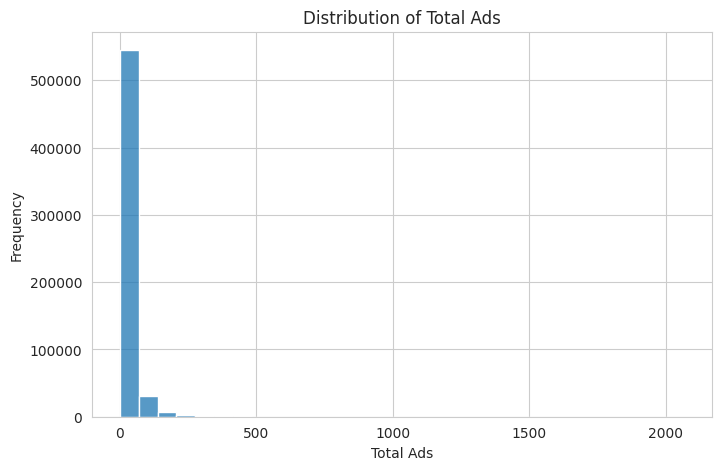

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["total ads"], bins=30)

plt.title("Distribution of Total Ads")

plt.xlabel("Total Ads")

plt.ylabel("Frequency")

plt.show()

## Cohen's h (Effect Size)

Conversion Rates

In [21]:
rates = df.groupby("test group")["converted"].mean()

ad_rate = rates["ad"]

psa_rate = rates["psa"]

print("Ad Conversion Rate :", round(ad_rate,4))

print("PSA Conversion Rate :", round(psa_rate,4))

Ad Conversion Rate : 0.0255
PSA Conversion Rate : 0.0179


Calculate Cohen's h

In [22]:
cohen_h = 2*np.arcsin(np.sqrt(ad_rate)) - 2*np.arcsin(np.sqrt(psa_rate))

print("Cohen's h =", round(cohen_h,4))

Cohen's h = 0.053


Interpretation

In [23]:
if abs(cohen_h) < 0.2:

    print("Small Effect Size")

elif abs(cohen_h) < 0.5:

    print("Medium Effect Size")

else:

    print("Large Effect Size")

Small Effect Size


 ## Mann–Whitney U Test

Create Groups

In [24]:
converted = df[df["converted"] == 1]["total ads"]

not_converted = df[df["converted"] == 0]["total ads"]

Perform Mann–Whitney U Test

In [25]:
u, p = mannwhitneyu(
    converted,
    not_converted
)

print("Statistic :", u)

print("P-value :", p)

Statistic : 7269106736.0
P-value : 0.0


Interpretation

In [26]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("There is a significant difference in Total Ads.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant difference found.")

Reject Null Hypothesis
There is a significant difference in Total Ads.


## Spearman Correlation

Calculate Correlation

In [27]:
corr, p = spearmanr(
    df["total ads"],
    df["converted"]
)

print("Correlation :", round(corr,4))

print("P-value :", p)

Correlation : 0.1927
P-value : 0.0


Interpretation

In [28]:
if p < 0.05:

    print("Significant Relationship")

else:

    print("No Significant Relationship")

Significant Relationship


## Chi-Square Test (Most Ads Day)

Create Contingency Table

In [29]:
table = pd.crosstab(
    df["most ads day"],
    df["converted"]
)

table

converted,0,1
most ads day,,
Friday,90551,2057
Monday,84216,2857
Saturday,79941,1719
Sunday,83301,2090
Thursday,81192,1790
Tuesday,75167,2312
Wednesday,78890,2018


Perform Chi-Square Test

In [30]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic :", chi2)

print("Degrees of Freedom :", dof)

print("P-value :", p)

Chi-Square Statistic : 410.0478857936585
Degrees of Freedom : 6
P-value : 1.932184379244731e-85


Interpretation

In [31]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("Most Ads Day affects Conversion.")

else:

    print("Fail to Reject Null Hypothesis")

    print("Most Ads Day does not affect Conversion.")

Reject Null Hypothesis
Most Ads Day affects Conversion.


## Advertisement Hour Analysis

Create Hour Groups

In [32]:
def hour_group(hour):

    if hour < 6:
        return "Night"

    elif hour < 12:
        return "Morning"

    elif hour < 18:
        return "Afternoon"

    else:
        return "Evening"

df["hour_group"] = df["most ads hour"].apply(hour_group)

### Chi-Square Test (Hour Group)

Create Contingency Table

In [33]:
table = pd.crosstab(
    df["hour_group"],
    df["converted"]
)

table

converted,0,1
hour_group,,
Afternoon,250787,7052
Evening,163600,4572
Morning,139292,2961
Night,19579,258


Perform Chi-Square Test

In [34]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic :", chi2)

print("Degrees of Freedom :", dof)

print("P-value :", p)

Chi-Square Statistic : 306.4767155017769
Degrees of Freedom : 3
P-value : 3.9443532339706767e-66


Interpretation

In [35]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("Advertisement Hour affects Conversion.")

else:

    print("Fail to Reject Null Hypothesis")

    print("Advertisement Hour does not affect Conversion.")

Reject Null Hypothesis
Advertisement Hour affects Conversion.


# Exploratory Data Analysis (EDA)

## Distribution of Test Groups

This visualization shows the number of users in each test group.

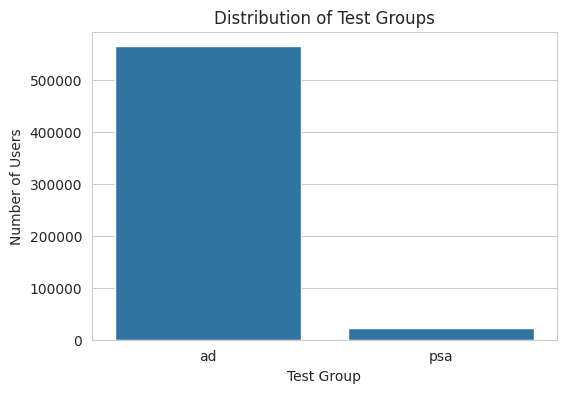

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="test group"
)

plt.title("Distribution of Test Groups")

plt.xlabel("Test Group")

plt.ylabel("Number of Users")

plt.show()

## Distribution of Conversion

This visualization shows the number of converted and non-converted users.

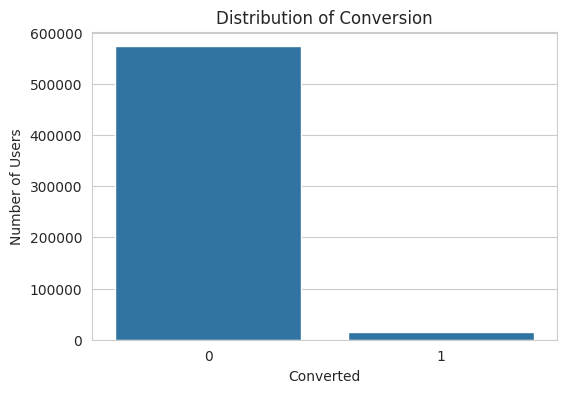

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="converted"
)

plt.title("Distribution of Conversion")

plt.xlabel("Converted")

plt.ylabel("Number of Users")

plt.show()

## Conversion Rate by Test Group

This chart compares the conversion rate between the Ad and PSA groups.

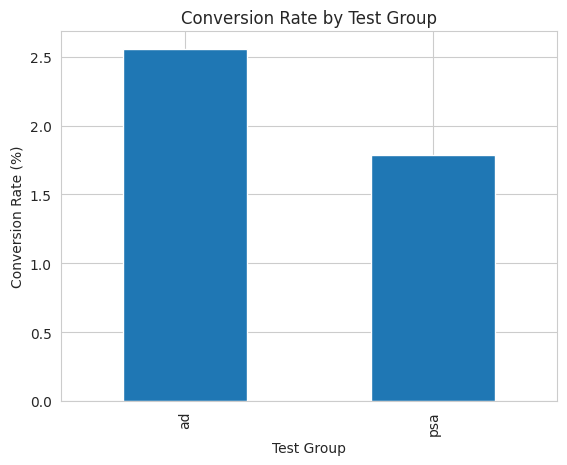

In [38]:
conversion = df.groupby("test group")["converted"].mean()*100

conversion.plot(kind="bar")

plt.title("Conversion Rate by Test Group")

plt.xlabel("Test Group")

plt.ylabel("Conversion Rate (%)")

plt.show()

## Distribution of Total Ads

This histogram shows how Total Ads are distributed among users.

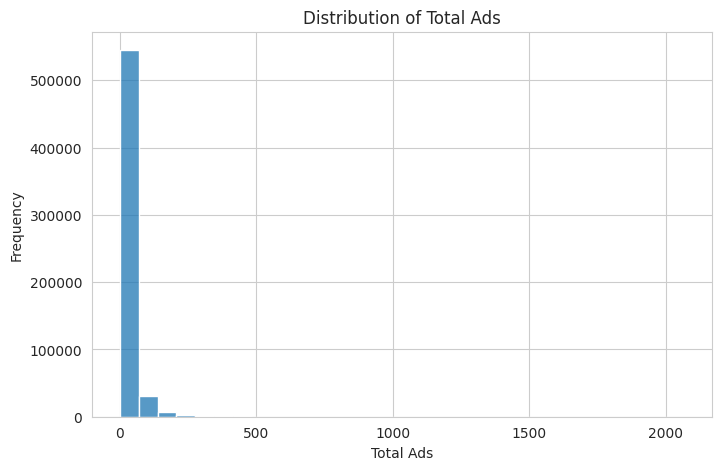

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="total ads",
    bins=30
)

plt.title("Distribution of Total Ads")

plt.xlabel("Total Ads")

plt.ylabel("Frequency")

plt.show()

## Total Ads by Test Group

This boxplot compares the Total Ads viewed by users in the Ad and PSA groups.

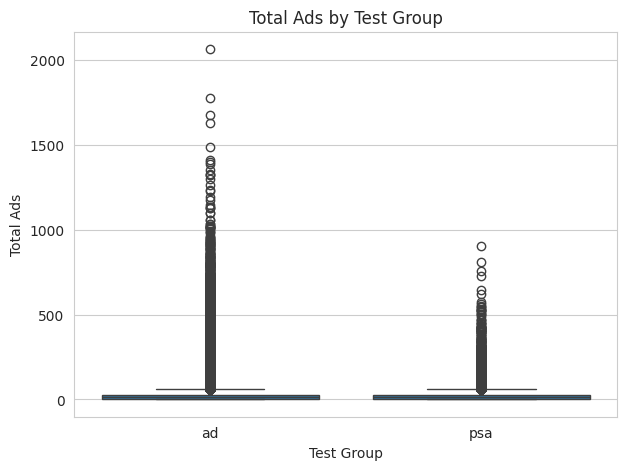

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="test group",
    y="total ads"
)

plt.title("Total Ads by Test Group")

plt.xlabel("Test Group")

plt.ylabel("Total Ads")

plt.show()

## Distribution of Most Ads Day

This visualization shows on which day users viewed the most advertisements.

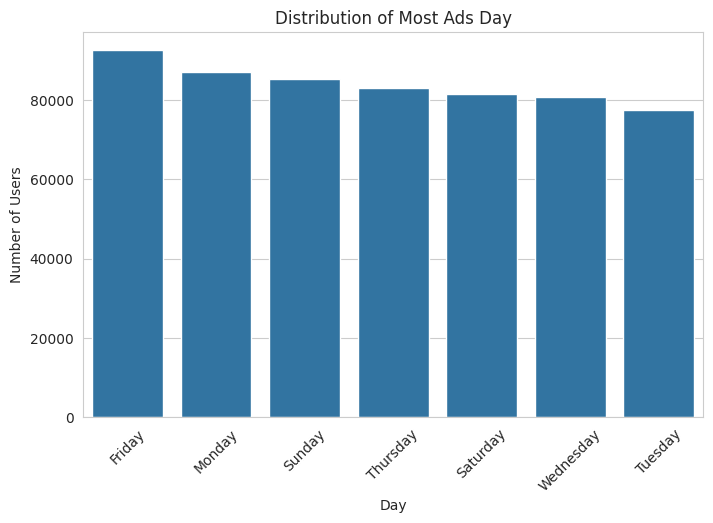

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="most ads day",
    order=df["most ads day"].value_counts().index
)

plt.title("Distribution of Most Ads Day")

plt.xlabel("Day")

plt.ylabel("Number of Users")

plt.xticks(rotation=45)

plt.show()

## Conversion Rate by Day

This chart compares conversion rates for different days of the week.

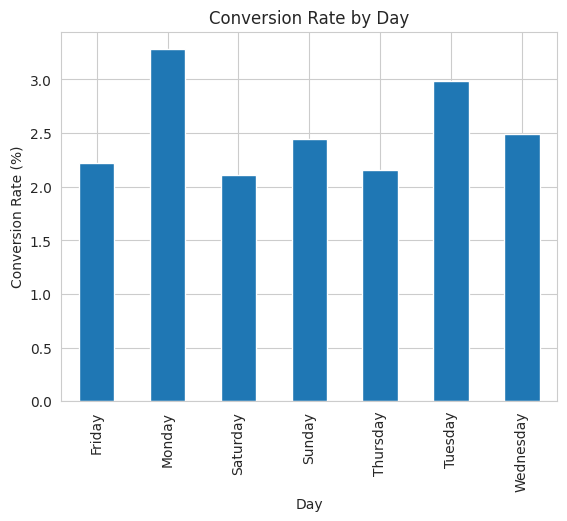

In [42]:
day_conversion = df.groupby("most ads day")["converted"].mean()*100

day_conversion.plot(kind="bar")

plt.title("Conversion Rate by Day")

plt.xlabel("Day")

plt.ylabel("Conversion Rate (%)")

plt.show()

## Distribution of Most Ads Hour

This histogram shows the hour during which users viewed the highest number of advertisements.

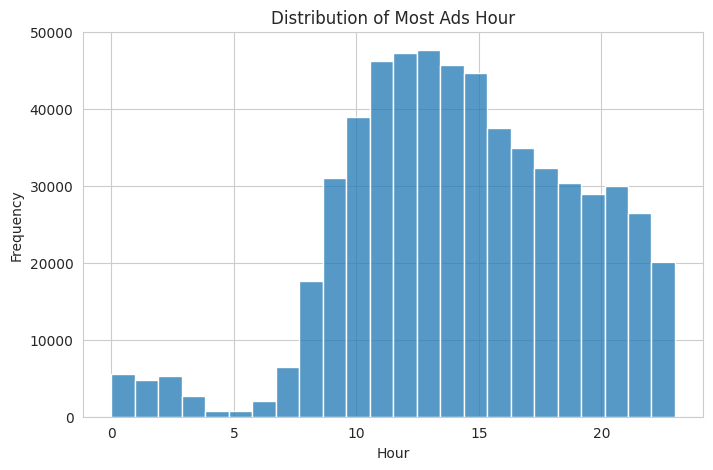

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="most ads hour",
    bins=24
)

plt.title("Distribution of Most Ads Hour")

plt.xlabel("Hour")

plt.ylabel("Frequency")

plt.show()

## Distribution of Hour Groups

This chart shows the number of users in each advertisement time group.

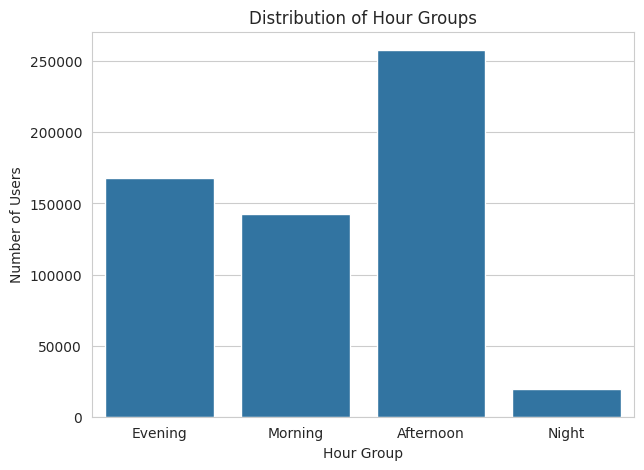

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="hour_group"
)

plt.title("Distribution of Hour Groups")

plt.xlabel("Hour Group")

plt.ylabel("Number of Users")

plt.show()

## Conversion Rate by Hour Group

This visualization compares conversion rates across different advertisement time groups.

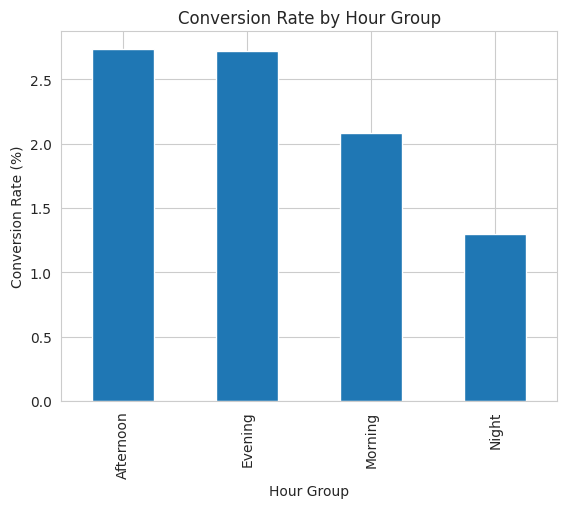

In [45]:
hour_conversion = df.groupby("hour_group")["converted"].mean()*100

hour_conversion.plot(kind="bar")

plt.title("Conversion Rate by Hour Group")

plt.xlabel("Hour Group")

plt.ylabel("Conversion Rate (%)")

plt.show()

## Correlation Heatmap

The heatmap displays the correlation among numerical variables.

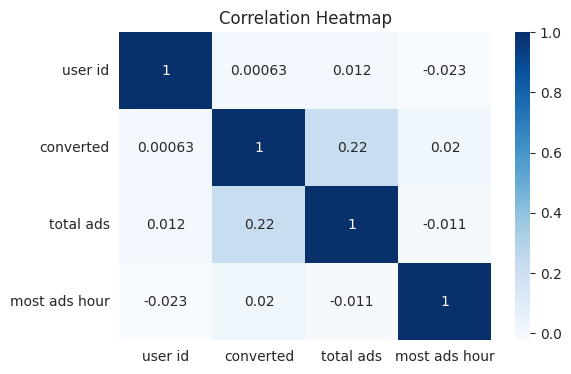

In [46]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

## Pairplot

The pairplot helps visualize relationships among numerical variables.

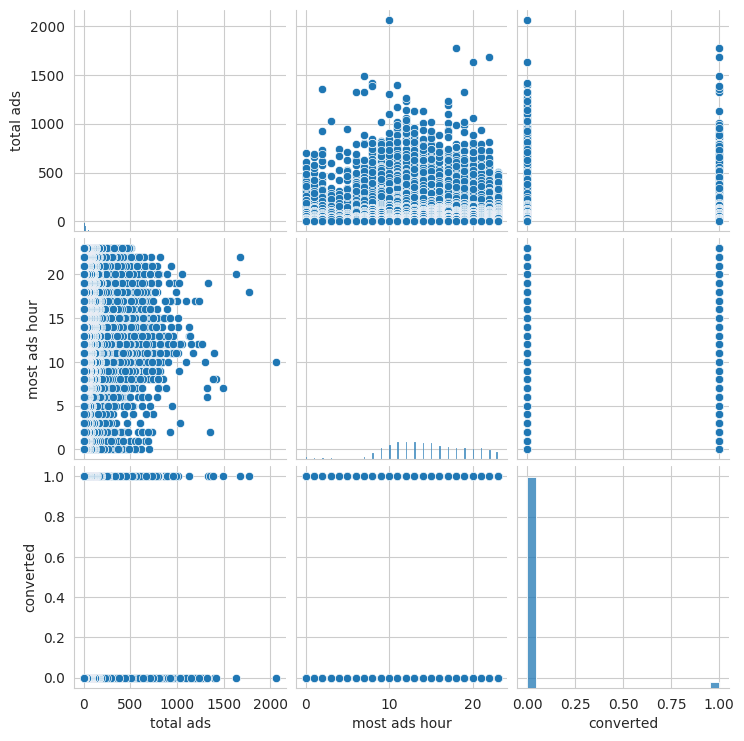

In [47]:
sns.pairplot(
    df[
        [
            "total ads",
            "most ads hour",
            "converted"
        ]
    ]
)

plt.show()

## Conversion by Test Group

This visualization compares converted and non-converted users in the Ad and PSA groups.

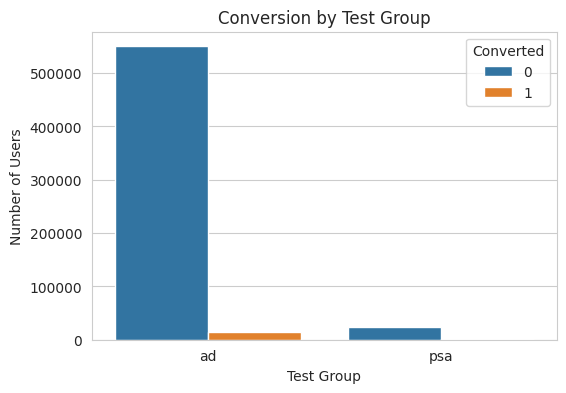

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="test group",
    hue="converted"
)

plt.title("Conversion by Test Group")

plt.xlabel("Test Group")

plt.ylabel("Number of Users")

plt.legend(title="Converted")

plt.show()

## Total Ads vs Conversion

This boxplot compares the distribution of Total Ads viewed by converted and non-converted users.

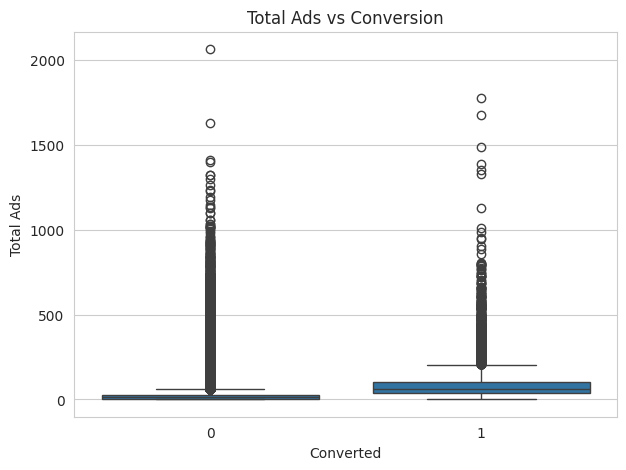

In [49]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="converted",
    y="total ads"
)

plt.title("Total Ads vs Conversion")

plt.xlabel("Converted")

plt.ylabel("Total Ads")

plt.show()

# Final Conclusion

## Project Summary

This project analyzed an A/B Testing dataset to compare the performance of two groups:

- **Ad Group** – Users who were shown advertisements.
- **PSA Group** – Users who were shown public service announcements.

The main objective was to understand whether advertisements improved user conversions and to identify the factors that influence conversion.

## What Was Analyzed?

The following analyses were performed during this project:

### Dataset Analysis
- Checked the dataset structure, data types, missing values, and duplicate records.
- Generated descriptive statistics to understand the overall dataset.
- Counted users across different categories.

### Statistical Analysis
- Compared conversion rates between the Ad and PSA groups.
- Tested whether the difference in conversion was statistically significant using the Chi-Square Test.
- Calculated 95% Confidence Intervals for conversion rates.
- Measured the practical impact of the difference using Cohen's h.
- Compared Total Ads viewed by converted and non-converted users using the Mann–Whitney U Test.
- Measured the relationship between Total Ads and Conversion using Spearman Correlation.
- Tested whether the day and time of advertisement influenced conversion.

### Exploratory Data Analysis (EDA)
- Explored the distribution of users in different test groups.
- Compared converted and non-converted users.
- Analyzed Total Ads distribution.
- Studied conversion rates across days and time groups.
- Visualized relationships between important variables using charts and a correlation heatmap.

## Key Business Insights

The analysis helps answer the following business questions:

- Which test group achieved a higher conversion rate?
- Does showing advertisements increase user conversions?
- Does showing more advertisements improve conversion?
- Which day of the week performs better for advertisements?
- Which time of day has higher conversion rates?
- Is the difference between the Ad and PSA groups meaningful?
- Which variables have the strongest relationship with conversion?


# Dashboard Opportunities

The analysis performed in this project can be transformed into interactive Tableau dashboards to monitor campaign performance, analyze user behavior, and support business decision-making.

---

# Dashboard 1: Executive Overview

**Purpose**

Provide a high-level summary of the A/B Testing campaign.

### KPI Cards
- Total Users
- Total Converted Users
- Overall Conversion Rate (%)
- Ad Group Conversion Rate (%)
- PSA Group Conversion Rate (%)
- Average Total Ads Viewed

### Visualizations
1. Test Group Distribution (Bar Chart)
2. Converted vs Non-Converted Users (Donut Chart)
3. Conversion Rate by Test Group (Bar Chart)
4. Most Ads Day Distribution (Bar Chart)
5. Hour Group Distribution (Bar Chart)

### Filters / Slicers
- Test Group
- Converted
- Most Ads Day
- Hour Group

---

# Dashboard 2: Conversion Analysis

**Purpose**

Compare conversion performance between different user groups.

### KPI Cards
- Ad Conversion Rate
- PSA Conversion Rate
- Conversion Difference
- Total Converted Users
- Total Non-Converted Users
- Average Conversion Rate

### Visualizations
1. Conversion by Test Group (Stacked Bar Chart)
2. Conversion Rate by Day (Bar Chart)
3. Conversion Rate by Hour Group (Bar Chart)
4. Total Ads vs Conversion (Box Plot)
5. Average Total Ads by Conversion Status (Bar Chart)

### Filters / Slicers
- Test Group
- Converted
- Most Ads Day
- Hour Group

---

# Dashboard 3: Advertisement & User Behavior

**Purpose**

Analyze advertisement exposure and user engagement.

### KPI Cards
- Average Total Ads Viewed
- Maximum Ads Viewed
- Minimum Ads Viewed
- Median Total Ads Viewed
- Average Ads Before Conversion

### Visualizations
1. Total Ads Distribution (Histogram)
2. Average Total Ads by Test Group (Bar Chart)
3. Average Total Ads by Most Ads Day (Bar Chart)
4. Average Total Ads by Hour Group (Bar Chart)
5. Scatter Plot (Total Ads vs Conversion)

### Filters / Slicers
- Test Group
- Converted
- Most Ads Day
- Hour Group

---

# Dashboard 4: Time Analysis & Business Insights

**Purpose**

Identify the best day and time for displaying advertisements and summarize business findings.

### KPI Cards
- Best Performing Test Group
- Best Performing Day
- Best Performing Hour Group
- Highest Conversion Rate
- Spearman Correlation

### Visualizations
1. Most Ads Day Distribution (Bar Chart)
2. Most Ads Hour Distribution (Histogram)
3. Conversion Rate by Day (Bar Chart)
4. Conversion Rate by Hour Group (Bar Chart)
5. Correlation Heatmap

### Filters / Slicers
- Test Group
- Converted
- Most Ads Day
- Hour Group

---

# Expected Business Outcomes

The Tableau dashboards will help answer the following business questions:

- Which test group achieved the highest conversion rate?
- Does showing advertisements improve user conversions?
- Does viewing more advertisements increase conversion?
- Which day produces the highest conversions?
- Which time of day performs best?
- Which user group should be targeted in future campaigns?
- What insights can support future marketing decisions?

## Recommendations

Based on this analysis, future marketing campaigns can:

- Focus on the advertisement strategy that produces a higher conversion rate.
- Display advertisements during the most effective days and time periods.
- Monitor conversion rates continuously to evaluate campaign performance.
- Use statistical testing before implementing major marketing decisions.
- Build interactive dashboards to monitor campaign performance in real time and support data-driven decision making.